In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from statsmodels.tools.sm_exceptions import InterpolationWarning
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.stats.diagnostic import het_breuschpagan

warnings.filterwarnings("ignore", category=InterpolationWarning)

In [194]:
import os
os.makedirs("fig", exist_ok=True)


## Выгрузка датасета и первичный анализ

In [195]:
df = pd.read_parquet('train.parquet')
print(df.shape)
print(df.columns)
df.head()

(517000, 35)
Index(['seq_ix', 'step_in_seq', 'need_prediction', '0', '1', '2', '3', '4',
       '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17',
       '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29',
       '30', '31'],
      dtype='object')


,seq_ix,step_in_seq,need_prediction,0,1,2,3,4,5,6,...,22,23,24,25,26,27,28,29,30,31
0,0,0,0,-0.080082,1.324564,0.637730,-1.091486,-0.859104,1.291364,-1.046394,...,0.876881,-1.425938,-0.104571,1.253508,-1.155514,-0.907224,1.361777,0.602751,1.265182,-0.495940
1,0,1,0,-1.243274,0.398425,-1.810485,-0.427042,0.303473,0.304587,-0.392796,...,0.669286,-0.720985,-1.144171,0.724269,-1.259564,0.181201,0.529757,-0.076843,1.111895,-1.171435
2,0,2,0,-0.124680,1.225580,0.139482,-0.967710,-0.769101,1.208697,-1.218701,...,0.742988,-1.381406,0.043121,1.205969,-1.062414,-0.739191,1.266046,0.856712,1.205016,-0.417057
3,0,3,0,-1.264455,0.494485,-1.041663,-0.587907,0.203893,0.437923,-0.479116,...,0.808542,-0.777047,-1.163911,0.801497,-1.280313,-0.090955,0.636906,-0.213926,1.121746,-1.364489
4,0,4,0,-0.882663,-0.223168,-1.229349,0.029471,0.459377,-0.232340,0.113789,...,0.286553,-0.114436,-0.730509,0.301325,-0.782454,0.486104,-0.172012,-0.016936,0.674722,-0.740237


In [196]:
id_cols = ["seq_ix", "step_in_seq", "need_prediction"]
feat_cols = [c for c in df.columns if c not in id_cols]
print(len(id_cols) + len(feat_cols))

35


Разделил на фичи последовательности и тенхические

In [197]:
print(df.dtypes)

seq_ix               int64
step_in_seq          int64
need_prediction      int64
0                  float64
1                  float64
2                  float64
3                  float64
4                  float64
5                  float64
6                  float64
7                  float64
8                  float64
9                  float64
10                 float64
11                 float64
12                 float64
13                 float64
14                 float64
15                 float64
16                 float64
17                 float64
18                 float64
19                 float64
20                 float64
21                 float64
22                 float64
23                 float64
24                 float64
25                 float64
26                 float64
27                 float64
28                 float64
29                 float64
30                 float64
31                 float64
dtype: object


In [198]:
df[feat_cols].isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
dtype: int64

Пропусков нет

In [199]:
stat = df[feat_cols].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T
stat["kurtosis"] = df[feat_cols].kurtosis(numeric_only=True)
stat["skew"] = df[feat_cols].skew(numeric_only=True)
desc.sort_values("kurtosis", ascending=False)

,count,mean,std,min,1%,5%,50%,95%,99%,max,kurtosis,skew
16,517000.0,-0.024390,0.991317,-5.199338,-2.317983,-1.632275,-0.024288,1.587270,2.281058,5.199338,0.295020,-0.034298
3,517000.0,-0.013578,1.010985,-5.199338,-2.374168,-1.635485,-0.020027,1.647367,2.322433,5.199338,0.278615,-0.030095
1,517000.0,0.022680,0.994129,-5.199338,-2.276932,-1.581343,0.013809,1.646643,2.380686,5.199338,0.255910,0.055264
2,517000.0,-0.006079,1.008178,-5.199338,-2.398546,-1.668118,-0.006287,1.643564,2.365690,5.199338,0.177696,-0.003492
24,517000.0,-0.010245,0.991879,-5.199338,-2.308916,-1.655679,-0.006489,1.616265,2.273809,5.199338,0.163818,-0.003928
11,517000.0,0.008588,0.985918,-5.199338,-2.287569,-1.622999,0.009162,1.614915,2.250856,5.199338,0.141284,0.023641
6,517000.0,-0.022507,1.001293,-5.199338,-2.435369,-1.644582,-0.018166,1.600028,2.312913,5.199338,0.137357,-0.034357
30,517000.0,0.006495,1.002600,-5.199338,-2.369056,-1.640186,0.008081,1.663222,2.331166,5.199338,0.106596,0.009674
19,517000.0,-0.018045,1.000008,-3.525064,-2.356301,-1.678100,-0.018436,1.625797,2.297837,5.199338,0.072119,0.023105
17,517000.0,-0.015188,0.986479,-5.199338,-2.313576,-1.648415,-0.003579,1.618279,2.231792,5.199338,0.067387,-0.063828


Судя по коэффициентам асимметрии (это просто трейтий момент, skew) распределения всех фичей +- симетричны (получается логарифмировать фичи не нужно для симетризации) и линейные модели будут в целом применимы.
Эксцесс (четвёртый момент) у основной массы фичей тоже близ к нулю, но только у первых ~5 фичей в той табличке будут тяжелее хвосты.


Отобразим какую-нибудь последовательность и спроецируем её на случайные 6 фичей. Так как сложно воспринимать 1000 элементов последовательностей на графике на первом графике я усреднил просто по 50 временным бинам. На втором графике я взял срез первых 50 бинов по несглаженным данным

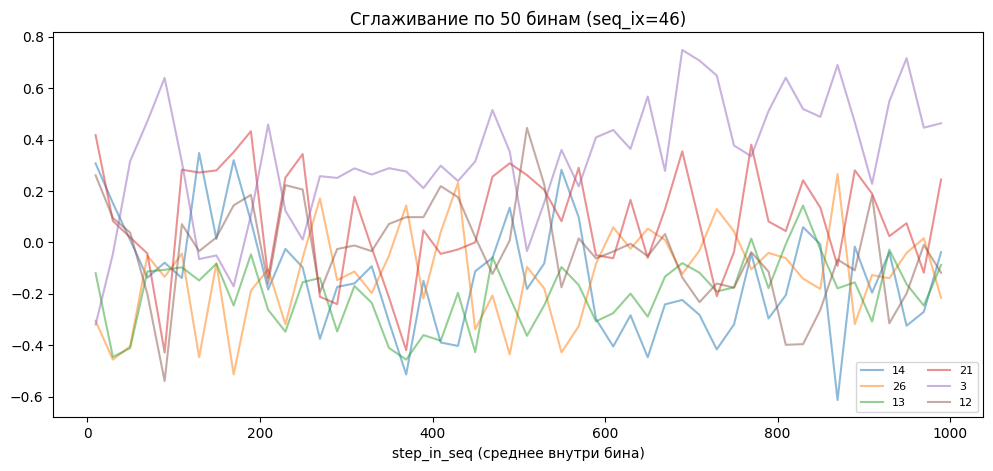

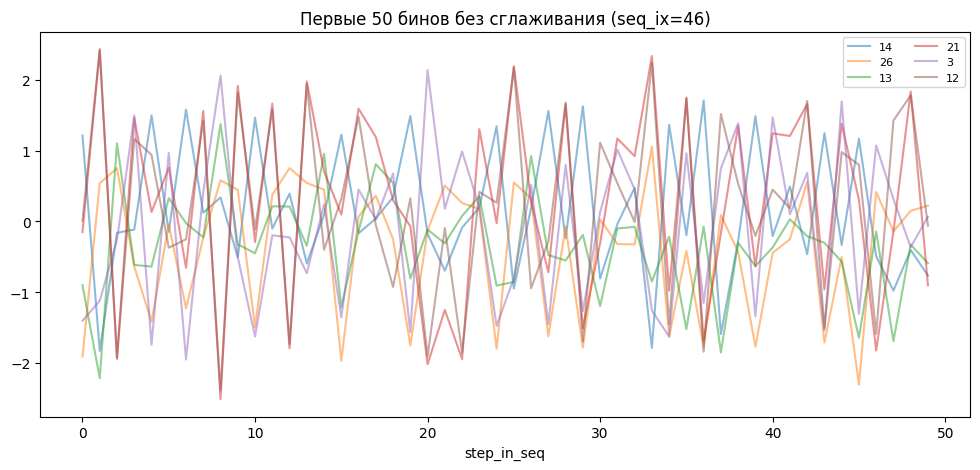

In [203]:
rnd_seq = 34
sub = df[df["seq_ix"] == rnd_seq].copy()
show_cols = list(rng.choice(feat_cols, size=6, replace=False))
n_bins = 50

sub["t_bin"] = pd.cut(sub["step_in_seq"], bins=n_bins, labels=False, include_lowest=True)
agg = sub.groupby("t_bin", as_index=True).agg(
    t_mean=("step_in_seq", "mean"),
    **{c: (c, "mean") for c in show_cols}
).reset_index(drop=True)
plt.figure(figsize=(12, 5))
for c in show_cols:
    plt.plot(agg["t_mean"], agg[c], label=str(c), alpha=0.5)
plt.title(f"Сглаживание по {n_bins} бинам (seq_ix={some_seq})")
plt.xlabel("step_in_seq (среднее внутри бина)")
plt.legend(ncol=2, fontsize=8)
plt.show()

sub50 = sub[sub["step_in_seq"] < 50]
plt.figure(figsize=(12, 5))
for c in show_cols:
    plt.plot(sub50["step_in_seq"], sub50[c], label=str(c), alpha=0.5)
plt.title(f"Первые 50 бинов без сглаживания (seq_ix={some_seq})")
plt.xlabel("step_in_seq")
plt.legend(ncol=2, fontsize=8)
plt.savefig("fig/seq_example2.png", dpi=300, bbox_inches="tight")
plt.show()

## EDA

### Факторность пространства

Немного опишу направленность идей дальнейшего eda:
Я проведу подготовку данных для обучения модели, основная идея подготовить сильные фичи, который будут хорошо описывать датасет, как мне кажется наиболее разумный подход это постараться описать волатильность ряда, так как несмотря на то, что данные анонимизированны, всё же было заявлено, что они финансовые (а в тех моделях которые я изучал на других курсах основное составляющее было знание о волатильности ценообразования). Также я постараюсь дать физическую интерпретацию данным (то есть возможно угадать что они из себя представляют).

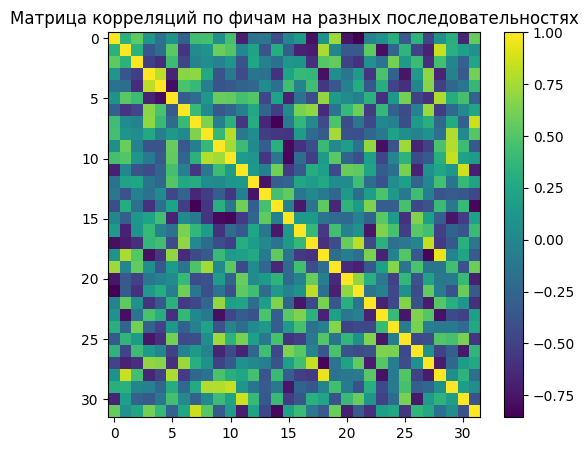

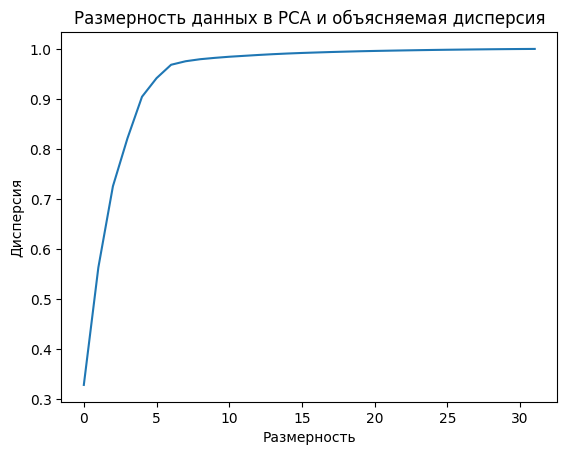

In [213]:
sub = df.sample(50000, random_state=0)
C = sub[feat_cols].corr()

plt.figure(figsize=(6,5))
plt.imshow(C.values, aspect="auto")
plt.title("Матрица корреляций по фичам на разных последовательностях")
plt.colorbar()
plt.show()
eigvals = np.linalg.eigvalsh(C.values)
eigvals = np.sort(eigvals)[::-1]

plt.figure()
plt.plot(np.cumsum(eigvals)/eigvals.sum())
plt.title("Размерность данных в PCA и объясняемая дисперсия")
plt.xlabel("Размерность")
plt.ylabel("Дисперсия")
plt.savefig("fig/ex_var.png", dpi=300, bbox_inches="tight")
plt.show()

Есть фичи которые коррелируемы (в целом коррелируемые фичи это плохо потому что когда gru будет учиться много лишних фичей будет и замедляется обучение). То есть мы можем перевести перевести вектора из $R^{32}$ в фактор пространство меньшей размерности.
Более того около k=10 размерность покрывает почти всю дисперсию, давайте даже точно выясним.

Эта логика так же имеет свою интерпретацию в финансовой математике (то есть существует понятие линейно зависимых активов и в целом разумно понижать ранг у портфеля).

In [137]:
Xn = df[feat_cols].to_numpy(np.float64)
U, S, Vt = np.linalg.svd(Xn, full_matrices=False)
pca_components = Vt[:8].T
factors = Xn @ pca_components
eigvals = (S ** 2) / (Xn.shape[0] - 1)
total_var = eigvals.sum()
explained = eigvals[:8].sum() / total_var
print(f" объясняемая дисперсия на 8 факторов: {explained:.4f}")
for k in range(8):
    corr_z = np.corrcoef(factors[:, k], z_resid)[0, 1]
    print(f" factor_{k}: std={factors[:,k].std():.4f}, корреляция с z_resid={corr_z:.4f}")

 объясняемая дисперсия на 8 факторов: 0.9753
 factor_0: std=3.2323, корреляция с z_resid=-0.1710
 factor_1: std=2.7280, корреляция с z_resid=0.0315
 factor_2: std=2.2593, корреляция с z_resid=-0.2000
 factor_3: std=1.7420, корреляция с z_resid=-0.0369
 factor_4: std=1.6304, корреляция с z_resid=0.0322
 factor_5: std=1.0856, корреляция с z_resid=0.4875
 factor_6: std=0.9143, корреляция с z_resid=0.0965
 factor_7: std=0.4775, корреляция с z_resid=0.0283


То есть с рядами мы можем потом работать в 8-фактор пространстве

### Волатильность

Основная цель напридумывать как можно больше сильных фичей, так как данные отнормированы я предлагаю в начале рассмотреть фичу соответствующую такой постановку $X ~ \sigma * \epsilon$, где $\mathbb{E}[\epsilon] = $, $Var[\epsilon] = 1$. Сигму можно по сути воспринимать как RMS (среднеквадратичное), потому что эта модель по сути описывает логику, что на каждом шаге в ряду вектор по каждой координате изменяется (то есть масштабируется), т е получается что эта модель описывает ситуацию, где на каждом шаге просто с каким-то коэфициентом масштабируется ($\epsilon$ просто отнормирован)

Поэтому далее я буду называть волатильностью "масштабы" векторов

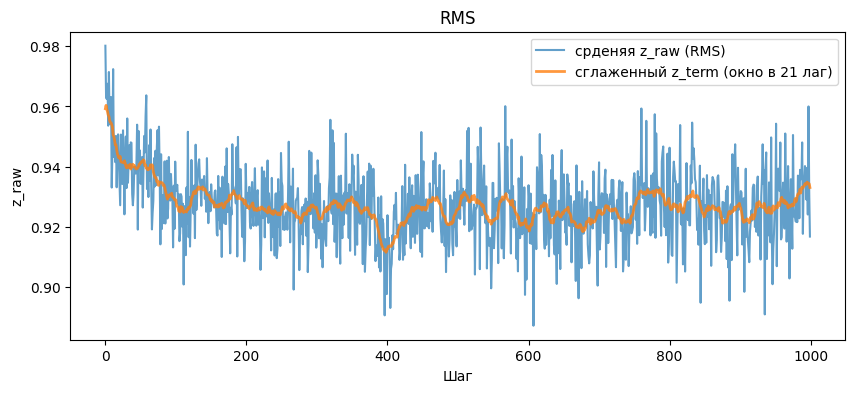

In [209]:
X = df[feat_cols].to_numpy(np.float64)
z_raw = np.sqrt((X**2).mean(axis=1))
z_by_step = pd.Series(z_raw).groupby(df["step_in_seq"]).mean().sort_index()
z_term = z_by_step.rolling(21, center=True, min_periods=1).mean()

plt.figure(figsize=(10,4))
plt.plot(z_by_step.index, z_by_step.values, label="срденяя z_raw (RMS)", alpha=.7)
plt.plot(z_term.index, z_term.values, label="сглаженный z_term (окно в 21 лаг)", linewidth=2, alpha=.8)
plt.title("RMS")
plt.xlabel("Шаг")
plt.ylabel("z_raw")
plt.legend()
plt.savefig("fig/rms_term.png", dpi=300, bbox_inches="tight")

plt.show()

RMS - это просто среднеквадратичная вектора, соответственно можно предположить, что если показатели слишком перегреты, то это какое-то шоковое состояние и размер вектора большое.

$z_{raw}=\sqrt{\mathbb{E}[x^2]}$ на самых первых шагах и затем быстро падает, затем волатильность примерно одинаковая. Видимо ряд нестационарный (стационарность можно будет проверить позже, ну и ожидаемо z_term действительно сглаженный и хорошо отражает общую волатильность ряда.

Давайте теперь проведём преобразование ряда. Идея следующая: $z_{term}$ описывает детерменированную часть ряда, а случайную часть обозначим за $z_{resid}$ то есть
$$z_{raw, i} = z_{ term, \frac{i}{21}} * z_{resid, i}$$
Тогда просто выразим $z_{resid} = z_{raw} / z_{term}$

посмотрим на acf по лагам $z_{resid}$ и распределение $z_{resid}$

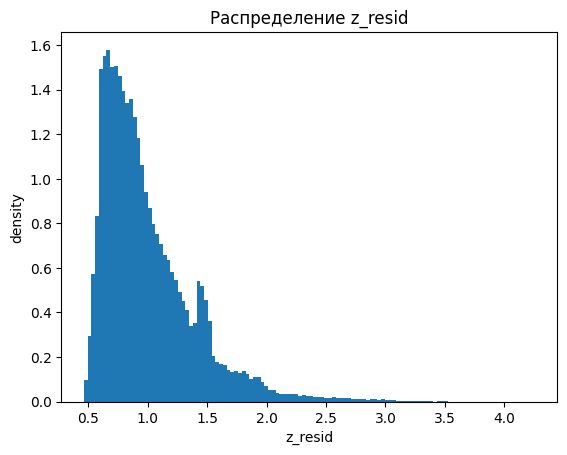

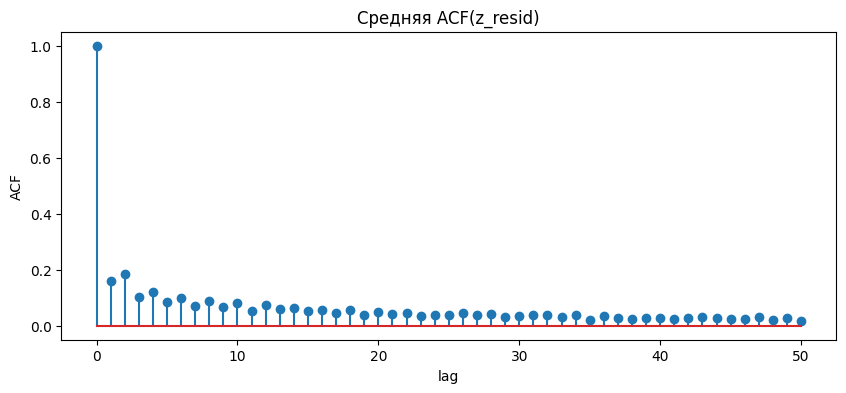

In [211]:
z_resid = z_raw / (z_term.loc[df["step_in_seq"]].to_numpy() + 1e-8)

plt.figure()
plt.hist(z_resid, bins=120, density=True)
plt.title("Распределение z_resid")
plt.xlabel("z_resid"); plt.ylabel("density")
plt.savefig("fig/z_resid_hist.png", dpi=300, bbox_inches="tight")
plt.show()

seqs = df["seq_ix"].drop_duplicates().sample(50, random_state=0).to_list()
acfs = []
for s in seqs:
    tmp = df[df["seq_ix"]==s].sort_values("step_in_seq")
    idx = tmp.index.to_numpy()
    zr = z_resid[idx]
    acfs.append(acf(zr, nlags=50, fft=True))
mean_acf = np.vstack(acfs).mean(axis=0)

plt.figure(figsize=(10,4))
plt.stem(range(len(mean_acf)), mean_acf)
plt.title("Средняя ACF(z_resid)")
plt.xlabel("lag")
plt.ylabel("ACF")
plt.savefig("fig/z_resid_acf.png", dpi=300, bbox_inches="tight")

plt.show()

В распределении $z_{resid}$ видна асимметрия то есть правый хвост более тяжёлый, более того видна вторая мода даже, то есть скорее всего в нашем ряде может быть два режима.

(на курсе по оценке активов, была концепция, что у рынка есть конечное количество состояний и периодически рынок меняет эти состояния, тем самым активы переходят в новые ценовые значения) Моя идея заключается в том чтобы развить ту концепцую и задать процесс случайного блуждания между этими состояниями.

ACF достаточно длинный, думаю до 15~ лага можно считать его заметным, то есть ряд имеет свойство персистентности (но это в целом очевидно, потому что ценообразование активов не прям случайное и почти никогда не может мгновенно упасть в 10 раз условно говоря, то есть если текущее значение достаточно нагретое, то следующим значением скорее всего не будет нулевое например). 

Можно ещё проверить на стационарность ряды:

In [141]:
adf_pvals = []
kpss_pvals = []
for _, sub in df.groupby("seq_ix", sort=False):
    zr = z_resid[sub.index.to_numpy()].astype(float)
    adf_pvals.append(adfuller(zr, autolag="AIC", regression="c")[1])
    kpss_pvals.append(kpss(zr)[1])

adf_pvals = np.array(adf_pvals, dtype=float)
kpss_pvals = np.array(kpss_pvals, dtype=float)

print("ADF медианная pvalue =", np.median(adf_pvals))
print("ADF процент реджекта гипотезы о нестационарности =", np.mean(adf_pvals < 0.05))

print("KPSS медианная p-value =", np.median(kpss_pvals))
print("KPSS процент реджекта гипотезы о стационарности =", np.mean(kpss_pvals < 0.05))

ADF медианная pvalue = 5.014161664035346e-19
ADF процент реджекта гипотезы о нестационарности = 0.9903288201160542
KPSS медианная p-value = 0.09346841313634505
KPSS процент реджекта гипотезы о стационарности = 0.4119922630560928


В целом ряд скорее стационарен, а то, что KPSS реджектить 41% скорее всего это из-за режимности.

Так как мы ранее выдвинули гипотзеу про режимность $z_{resid}$ и на графике распределения достаточно заметно, что две моды и ассиметрия высокая, то можно попробовать задать марковский процесс для перехода между состояниями (мы будем рассматривать только два состояния).

**Теоретическая выкладка по скрытой скрытой марковской модели:**

Есть набор независимых последовательностей, индексируемых $n=1,\dots,N$.
Внутри каждой последовательности $n$ есть временные шаги $t=1,\dots,T_n$ и наблюдения

$$
o_{n,t} := z_{resid}(n,t)\in\mathbb{R}.
$$

Мы хотим ввести скрытую дискретную переменную режима $s_{n,t}\in\{1,\dots,K\}$ и восстановить для каждого шага
апостериорные вероятности режимов:

$$
\gamma_{n,t}(k) := \mathbb{P}(s_{n,t}=k \mid o_{n,1:T_n}),
$$
Начальное распределение:

$$
\pi_k := \mathbb{P}(s_{n,1}=k), \qquad \sum_{k=1}^K \pi_k = 1.
$$

Матрица переходов:

$$
A_{ij} := \mathbb{P}(s_{n,t}=j \mid s_{n,t-1}=i), 
\qquad \sum_{j=1}^K A_{ij}=1.
$$

Марковское свойство:

$$
\mathbb{P}(s_{n,t}\mid s_{n,1:t-1})=\mathbb{P}(s_{n,t}\mid s_{n,t-1}).
$$

Для скаляра $z_{resid}$ типичный выбор — гауссовская эмиссия:
$$
o_{n,t}\mid (s_{n,t}=k)\sim \mathcal{N}(\mu_k,\sigma_k^2).
$$

Плотность эмиссии:
$$
b_k(o) := p(o\mid s=k)=\mathcal{N}(o;\mu_k,\sigma_k^2).
$$
Для одной последовательности $n$ и фиксированной цепочки состояний $s_{1:T}$:

$$
p(o_{1:T}, s_{1:T})
=
\pi_{s_1}\, b_{s_1}(o_1)\,
\prod_{t=2}^{T} A_{s_{t-1},s_t}\, b_{s_t}(o_t).
$$

Маргинальное правдоподобие наблюдений:
$$
p(o_{1:T})=\sum_{s_{1:T}} p(o_{1:T}, s_{1:T}).
$$
Для всех последовательностей:

$$
\mathcal{L}(\theta)=\sum_{n=1}^N \log p(o_{n,1:T_n}\,;\theta),
$$

где $\theta=\{\pi, A, (\mu_k,\sigma_k^2)_{k=1}^K\}$.

Вывод вероятностей режимов:

**Forward (альфа)**
Определим

$$
\alpha_t(k) := p(o_{1:t}, s_t=k).
$$

Рекурсии:
$$
\alpha_1(k)=\pi_k\, b_k(o_1),
$$

$$
\alpha_{t}(j)= b_j(o_t)\sum_{i=1}^K \alpha_{t-1}(i)\,A_{ij}.
$$

**Backward (бета)**
Определим

$$
\beta_t(k):=p(o_{t+1:T}\mid s_t=k).
$$

Рекурсии:
$$
\beta_T(k)=1,
$$

$$
\beta_t(i)=\sum_{j=1}^K A_{ij}\, b_j(o_{t+1})\, \beta_{t+1}(j).
$$

**Апостериорные вероятности режимов (гамма)**
Сглаженные вероятности (используют всю последовательность):

$$
\gamma_t(k)=p(s_t=k\mid o_{1:T})
=\frac{\alpha_t(k)\beta_t(k)}{\sum_{r=1}^K \alpha_T(r)}.
$$

(Здесь $p(o_{1:T})=\sum_{r=1}^K \alpha_T(r)$.)

**Апостериорные вероятности переходов (кси)**
Для обучения переходов:
$$
\xi_t(i,j)=p(s_t=i,s_{t+1}=j\mid o_{1:T})
=\frac{\alpha_t(i)A_{ij}b_j(o_{t+1})\beta_{t+1}(j)}{p(o_{1:T})}.
$$


Обучение параметров (Baum–Welch / EM)

**E-шаг**
По текущим $\theta$ считаем $\gamma_t(k)$ и $\xi_t(i,j)$ для всех $t$ (и для всех последовательностей $n$).

**M-шаг (обновления)**
Начальные вероятности (для каждой последовательности сброс на $t=1$; при множестве последовательностей — усреднение):

$$
\pi_k^{new}=\frac{1}{N}\sum_{n=1}^N \gamma_{n,1}(k).
$$

Переходы:

$$
A_{ij}^{new}
=
\frac{\sum_{n=1}^N\sum_{t=1}^{T_n-1} \xi_{n,t}(i,j)}
{\sum_{n=1}^N\sum_{t=1}^{T_n-1} \gamma_{n,t}(i)}.
$$

Параметры гауссовской эмиссии:

$$
\mu_k^{new}
=
\frac{\sum_{n=1}^N\sum_{t=1}^{T_n} \gamma_{n,t}(k)\, o_{n,t}}
{\sum_{n=1}^N\sum_{t=1}^{T_n} \gamma_{n,t}(k)},
$$

$$
(\sigma_k^2)^{new}
=
\frac{\sum_{n=1}^N\sum_{t=1}^{T_n} \gamma_{n,t}(k)\, (o_{n,t}-\mu_k^{new})^2}
{\sum_{n=1}^N\sum_{t=1}^{T_n} \gamma_{n,t}(k)}.
$$


С помощью HMM мы насчитаем вероятности переходов в каждом состоянии т. е.:
$$
\gamma_{n,t}(1),\ \gamma_{n,t}(2),\qquad \gamma_{n,t}(1)+\gamma_{n,t}(2)=1.
$$

Эти веса процесса мы (A, $\pi$) обучим на train а потом будем использовать для усреднения предсказания в регрессии и в качестве отдельной фичи в gru.

Предварительно вычислим количество режимов оптимальное в этой моделе (визуально ранее было предположение, что их только 2).

### Приращения

В начале проверим на примере одной фичи её на гетероскедантичность (например самую первую и постараемся её преобразовать к гомоскедантичности).

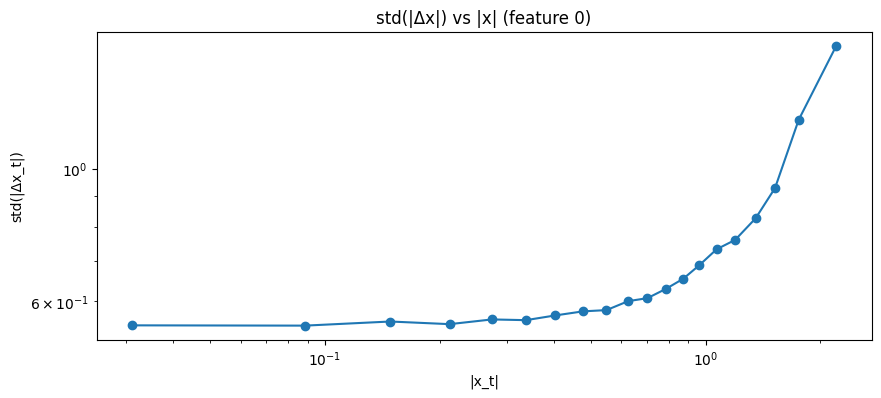

Тест Бройша - Пагана p-value: 0.0 | F p-value: 0.0
corr(log|x|, log|dx|) = 0.134
LM stat: 34751.79840837222
F stat scaled : 37258.98702526763


In [204]:
c = feat_cols[0]
x = df[c].to_numpy(np.float64)
dx = (df.groupby("seq_ix")[c].shift(-1).to_numpy(np.float64) - x)
m = np.isfinite(x) & np.isfinite(dx) & (np.abs(x) > 1e-12) & (np.abs(dx) > 1e-12)
abs_x, abs_dx = np.abs(x[m]), np.abs(dx[m])
logx, logdx = np.log(abs_x), np.log(abs_dx)

u = pd.DataFrame({"abs_x": abs_x, "abs_dx": abs_dx})
u["bin"] = pd.qcut(u["abs_x"], q=20, duplicates="drop")
g2 = u.groupby("bin", observed=True).agg(x_med=("abs_x","median"), dx_std=("abs_dx","std")).sort_values("x_med")

plt.figure(figsize=(10,4))
plt.plot(g2["x_med"], g2["dx_std"], marker="o")
plt.xscale("log"); plt.yscale("log")
plt.title(f"std(|Δx|) vs |x| (feature {c})")
plt.xlabel("|x_t|"); plt.ylabel("std(|Δx_t|)")
plt.savefig("fig/std_dx_vs_x.png", dpi=300, bbox_inches="tight")

plt.show()

lm_stat, lm_p, f_stat, f_p = het_breuschpagan(dx[m] - dx[m].mean(), sm.add_constant(logx))
print(f"Тест Бройша - Пагана p-value: {lm_p} | F p-value: {f_p}")
print(f"corr(log|x|, log|dx|) = {np.corrcoef(logx, logdx)[0,1]:.3f}")
print("LM stat:", lm_stat)
print("F stat scaled :", f_stat)

Данные сильно гетероскедантичные, попробуем допиться чего-то более близко к гомоскедантичности. По графику так же видно, что по мере увеличения x, дисперсия изменения растёт, то есть это прямой показатель гетероскедантичности.

В деривативах цены форвардов/акций часто задаются моделью слупа через броуновское движение (модель блэк шоулза, биноминальная модель и т п).

То есть задаётся таким стохастическим дифференциальным уравнением:
$$
dS_t = \mu S_t,dt + \sigma S_t^{\beta}, dW_t,
$$
где:

* $W_t$ — броуновское движение,
* $\mu$ — дрейф,
* $\sigma>0$ — масштаб (волатильность),
* $\beta$ — параметр

Интерпретация параметра

* $\beta = 1$: геометрическое броуновское движение (Блэка Шоулза): волатильность пропорциональна уровню (мультипликативный шум).
* $\beta = 0$: "нормальная" модель: волатильность примерно постоянна в абсолютных единицах (аддитивный шум).
* $0<\beta<1$: промежуточный случай.

Условная дисперсия малых приращений:
$$
\mathrm{Var}(dS_t \mid S_t)\approx \sigma^2 S_t^{2\beta}, dt,
$$
то есть условная дисперсия приращения — степенная функция.

Покажем как это в дискретном виде будет:

На малом шаге (\Delta t) получаем приближение:
$$
|\Delta S_t| \approx \sigma |S_t|^{\beta}\sqrt{\Delta t},|\varepsilon_t|,
\qquad \varepsilon_t\sim\mathcal{N}(0,1).
$$
Берём логарифм:
$$
\log|\Delta S_t| \approx \text{const} + \beta \log|S_t| + \text{шум}.
$$
Отсюда регрессия $\log|dx|$ на $\log|x|$ оценивает $\beta$, а нормировка
$$
\frac{dx}{|x|^{\beta}}
$$
пытается "выровнять" дисперсию приращений по разным уровням.



In [205]:
c = feat_cols[0]
x = df2[c].to_numpy(np.float64)
dx = np.diff(x)
xlag = x[:-1]

m = (np.abs(dx)>1e-12) & (np.abs(xlag)>1e-12)
y = np.log(np.abs(dx[m]))
Xr = sm.add_constant(np.log(np.abs(xlag[m])))
res = sm.OLS(y, Xr).fit()
beta = res.params[1]
print("beta:", beta)

d_sabr = dx / (np.abs(xlag)**beta + 1e-8)

beta: 0.1832508260711853


CEV beta = 0.18316694295493863

Breusch–Pagan vs log|x|:
  RAW: LM=34751.825, p=0 | F=37259.018, p=0
  CEV: LM=45.138, p=1.84e-11 | F=45.142, p=1.83e-11


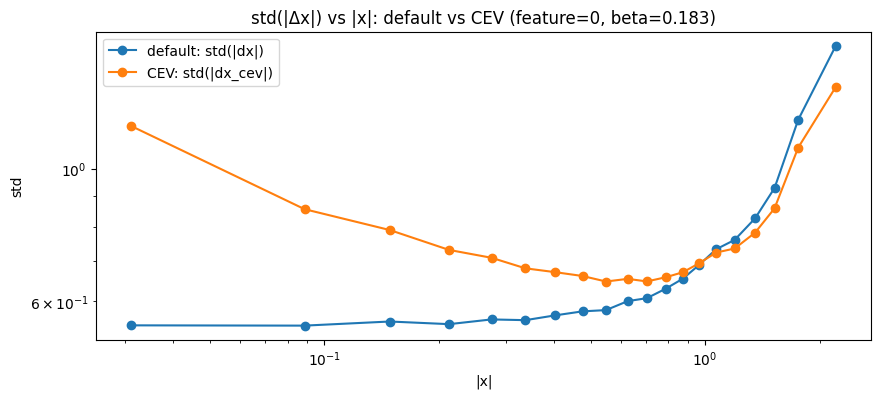

In [ ]:
eps = 1e-8
c = feat_cols[0] 
tmp = df2.sort_values(["seq_ix", "step_in_seq"]).copy()
x = tmp[c].to_numpy(np.float64)
xnext = tmp.groupby("seq_ix")[c].shift(-1).to_numpy(np.float64)
dx = xnext - x
xlag = x

base = np.isfinite(dx) & np.isfinite(xlag) & (np.abs(dx) > 1e-12) & (np.abs(xlag) > 1e-12)
abs_x = np.abs(xlag)
abs_dx = np.abs(dx)

logx = np.log(abs_x[base] + eps)
logdx = np.log(abs_dx[base] + eps)

Xr = sm.add_constant(logx)
res = sm.OLS(logdx, Xr).fit()
beta = float(res.params[1])
print("CEV beta =", beta)

dx_cev = np.full_like(dx, np.nan, dtype=np.float64)
dx_cev[base] = dx[base] / (abs_x[base]**beta + eps)

m = base & np.isfinite(dx_cev) & (np.abs(dx_cev) > 1e-12)
lx = np.log(np.abs(xlag[m]) + eps)

resid_raw = dx[m] - np.mean(dx[m])
bp_raw = het_breuschpagan(resid_raw, sm.add_constant(lx)) 

resid_cev = dx_cev[m] - np.mean(dx_cev[m])
bp_cev = het_breuschpagan(resid_cev, sm.add_constant(lx))

print("\nBreusch–Pagan vs log|x|:")
print(f"  RAW: LM={bp_raw[0]:.3f}, p={bp_raw[1]:.3g} | F={bp_raw[2]:.3f}, p={bp_raw[3]:.3g}")
print(f"  CEV: LM={bp_cev[0]:.3f}, p={bp_cev[1]:.3g} | F={bp_cev[2]:.3f}, p={bp_cev[3]:.3g}")

u = pd.DataFrame({
    "abs_x": np.abs(xlag[m]),
    "abs_dx": np.abs(dx[m]),
    "abs_dcev": np.abs(dx_cev[m]),
})

u["bin"] = pd.qcut(u["abs_x"], q=20, duplicates="drop")
g = u.groupby("bin", observed=True).agg(
    x_med=("abs_x", "median"),
    std_raw=("abs_dx", "std"),
    std_cev=("abs_dcev", "std"),
).sort_values("x_med")

plt.figure(figsize=(10,4))
plt.plot(g["x_med"], g["std_raw"], marker="o", label="default: std(|dx|)")
plt.plot(g["x_med"], g["std_cev"], marker="o", label="CEV: std(|dx_cev|)")
plt.xscale("log"); plt.yscale("log")
plt.title(f"std(|Δx|) vs |x|: default vs CEV (feature={c}, beta={beta:.3f})")
plt.xlabel("|x|"); plt.ylabel("std")
plt.legend()
plt.savefig("fig/cev_binned.png", dpi=300, bbox_inches="tight")

plt.show()


Видно что по прежнему гетероскедастичность осталась но статистика теста значительно упала, а значит это дало хорошое улучшение.

## Построение VAR(1) для X факторов

Проверка на мультиколлинеарность

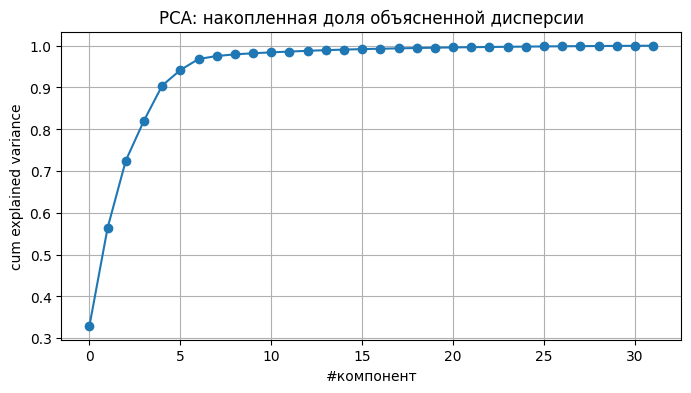

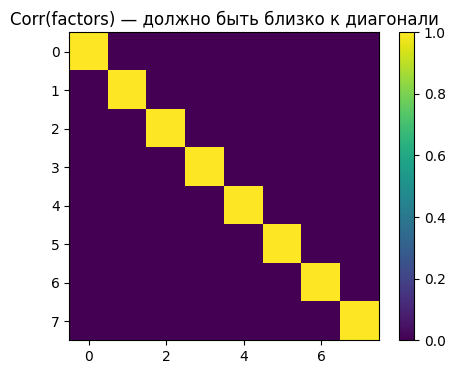

max |offdiag corr| = 2.5507622497048406e-14


In [ ]:

df2 = df.copy()
X = df2[feat_cols].to_numpy(np.float64)

C = np.cov(X, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

expl = eigvals / eigvals.sum()

plt.figure(figsize=(8,4))
plt.plot(np.cumsum(expl), marker="o")
plt.title("PCA: накопленная доля объясненной дисперсии")
plt.xlabel("#компонент"); plt.ylabel("cum explained variance")
plt.grid(True)
plt.savefig("fig/ex_var.png", dpi=300, bbox_inches="tight")
plt.show()

F = 8 
P = eigvecs[:, :F] 
factors = X @ P
CorrF = np.corrcoef(factors, rowvar=False)

plt.figure(figsize=(5,4))
plt.imshow(CorrF, aspect="auto")
plt.title("Corr(factors) — должно быть близко к диагонали")
plt.colorbar()
plt.savefig("fig/corr8_var.png", dpi=300, bbox_inches="tight")
plt.show()

print("max |offdiag corr| =", np.max(np.abs(CorrF - np.eye(F))))


In [173]:
def adf_share_per_seq(series_2d, col_ix, regression="c"):
    pvals = []
    for _, sub in df2.groupby("seq_ix", sort=False):
        x = series_2d[sub.index.to_numpy(), col_ix]
        pvals.append(adfuller(x, autolag="AIC", regression=regression)[1])
    pvals = np.array(pvals, dtype=float)
    return float(np.nanmedian(pvals)), float(np.nanmean(pvals < 0.05))

meds, shares = [], []
for j in range(F):
    med_p, share = adf_share_per_seq(factors, j, regression="c")
    meds.append(med_p); shares.append(share)

pd.DataFrame({"factor": np.arange(F), "adf_p_median": meds, "adf_reject_share_5%": shares})

,factor,adf_p_median,adf_reject_share_5%
0,0,1.074188e-14,0.990329
1,1,1.645154e-17,0.984526
2,2,7.344526e-26,0.990329
3,3,2.375296e-27,0.990329
4,4,5.361104e-28,0.988395
5,5,1.102298e-20,0.990329
6,6,3.609655e-23,0.986460
7,7,9.808665e-30,0.994197


In [ ]:
z_raw = np.sqrt((X**2).mean(axis=1))
z_by_step = pd.Series(z_raw).groupby(df2["step_in_seq"]).mean().sort_index()
z_term = z_by_step.rolling(21, center=True, min_periods=1).mean()
z_resid = z_raw / (z_term.loc[df2["step_in_seq"]].to_numpy(np.float64) + 1e-8)

thr = float(np.median(z_resid))
gamma_high = (z_resid > thr).astype(np.float64)
gamma_low  = 1.0 - gamma_high

print("thr =", thr, "share_high =", gamma_high.mean())


thr = 0.8947884957355627 share_high = 0.5


In [ ]:
def fit_weighted_ridge_var1(F_t, F_next, w, lam=1e-3):
    """
    F_t, F_next: (M,F)
    w: (M,) веса
    возвращает A(F,F), c(F,)
    """
    w = w.reshape(-1,1)
    Xr = np.hstack([F_t, np.ones((F_t.shape[0],1))]) 
    XtW = (Xr * w).T
    G = XtW @ Xr
    G += lam * np.eye(G.shape[0])
    B = np.linalg.solve(G, XtW @ F_next)   
    A = B[:-1,:].T                      
    c = B[-1,:]                                 
    return A, c

same_seq_next = (df2["seq_ix"].to_numpy()[:-1] == df2["seq_ix"].to_numpy()[1:])
F_t = factors[:-1][same_seq_next]
F_next = factors[1:][same_seq_next]

wH = gamma_high[:-1][same_seq_next]
wL = gamma_low[:-1][same_seq_next]

A_L, c_L = fit_weighted_ridge_var1(F_t, F_next, wL, lam=1e-3)
A_H, c_H = fit_weighted_ridge_var1(F_t, F_next, wH, lam=1e-3)

print("A_L shape", A_L.shape, "A_H shape", A_H.shape)


A_L shape (8, 8) A_H shape (8, 8)


In [ ]:
def residuals(F_t, F_next, A, c):
    pred = (F_t @ A.T) + c.reshape(1,-1)
    return F_next - pred

E_L = residuals(F_t, F_next, A_L, c_L)
E_H = residuals(F_t, F_next, A_H, c_H)

def corr_eps_with_regressors(E, F_t):
    C = np.corrcoef(np.hstack([E, F_t]).T)
    Fdim = F_t.shape[1]
    Ce = C[:Fdim, Fdim:] 
    return float(np.nanmax(np.abs(Ce)))

print("max |Corr(e, f_t)| low =", corr_eps_with_regressors(E_L, F_t))
print("max |Corr(e, f_t)| high=", corr_eps_with_regressors(E_H, F_t))


max |Corr(e, f_t)| low = 0.23224734945435363
max |Corr(e, f_t)| high= 0.053285591411178425


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_pvals(E, lags=20):
    p = []
    for j in range(E.shape[1]):
        pv = acorr_ljungbox(E[:,j], lags=[lags], return_df=True)["lb_pvalue"].iloc[0]
        p.append(pv)
    return np.array(p)

pL = ljung_box_pvals(E_L, lags=20)
pH = ljung_box_pvals(E_H, lags=20)

print("Ljung-Box p<0.05 share: low =", float(np.mean(pL < 0.05)), "high =", float(np.mean(pH < 0.05)))


Ljung-Box p<0.05 share: low = 1.0 high = 1.0


In [185]:
from statsmodels.stats.diagnostic import het_arch

def arch_share(E, lags=10):
    ps = []
    for j in range(E.shape[1]):
        p = het_arch(E[:,j], nlags=lags)[1]  # p-value
        ps.append(p)
    ps = np.array(ps)
    return float(np.mean(ps < 0.05)), float(np.nanmedian(ps))

print("ARCH reject share / median p (low):", arch_share(E_L))
print("ARCH reject share / median p (high):", arch_share(E_H))


ARCH reject share / median p (low): (1.0, 0.0)
ARCH reject share / median p (high): (1.0, 0.0)


In [186]:
def spectral_radius(A):
    vals = np.linalg.eigvals(A)
    return float(np.max(np.abs(vals)))

rhoL = spectral_radius(A_L)
rhoH = spectral_radius(A_H)
print("spectral radius low =", rhoL)
print("spectral radius high=", rhoH)


spectral radius low = 0.7806008461086698
spectral radius high= 0.8694698377774049


### подбор p var(p)

In [ ]:
df2 = df.copy()
X = df2[feat_cols].to_numpy(np.float64)

C = np.cov(X, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]

F = 8
P = eigvecs[:, :F]        
F_all = X @ P                   

z_raw = np.sqrt((X**2).mean(axis=1))
z_by_step = pd.Series(z_raw).groupby(df2["step_in_seq"]).mean().sort_index()
z_term = z_by_step.rolling(21, center=True, min_periods=1).mean()
z_resid = z_raw / (z_term.loc[df2["step_in_seq"]].to_numpy(np.float64) + 1e-8)

thr = float(np.median(z_resid))
w_high = (z_resid > thr).astype(np.float64)
w_low = 1.0 - w_high

seqs = df2["seq_ix"].drop_duplicates().to_numpy()
rng = np.random.default_rng(0)
rng.shuffle(seqs)
n_val = int(0.2 * len(seqs))
val_seqs = set(seqs[:n_val])
is_val = df2["seq_ix"].isin(val_seqs).to_numpy()


In [ ]:
def make_varp_xy(F_series, seq_ix, weights, p):
    """
    Строим пары: (lags at time t) -> F_{t+1}, t = p-1..L-2 внутри каждого seq.
    X: [F_t, F_{t-1}, ..., F_{t-p+1}, 1]  размер (M, F*p+1)
    Y: F_{t+1}                            размер (M, F)
    w: weights at time t                  размер (M,)
    """
    X_list, Y_list, w_list = [], [], []
    for s, sub in df2.groupby("seq_ix", sort=False):
        idx = sub.index.to_numpy()
        f = F_series[idx] 
        ww = weights[idx]
        L = f.shape[0]
        if L <= p: 
            continue
        for t in range(p-1, L-1):
            if t+1 >= L: 
                break
            lags = [f[t - j] for j in range(p)]
            xrow = np.concatenate(lags + [np.ones((1,))], axis=0) 
            X_list.append(xrow)
            Y_list.append(f[t+1])
            w_list.append(ww[t])
    X = np.vstack(X_list).astype(np.float64)
    Y = np.vstack(Y_list).astype(np.float64)
    w = np.array(w_list, dtype=np.float64)
    return X, Y, w

def fit_weighted_ridge(X, Y, w, lam=1e-3):
    """
    Weighted ridge: (X'WX + lam I)^{-1} X'W Y
    X: (M,D), Y:(M,F), w:(M,)
    Возвращает B: (D,F)
    """
    w = w.reshape(-1, 1)
    XtW = (X * w).T
    G = XtW @ X + lam * np.eye(X.shape[1])
    B = np.linalg.solve(G, XtW @ Y)
    return B

def predict_with_B(X, B):
    return X @ B  # (M,F)


    p  val_mse_factors
0   1         3.228321
1   2         3.078933
2   3         3.040981
3   4         3.009664
4   5         2.996109
5   6         2.980911
6   7         2.973454
7   8         2.964911
8   9         2.960862
9  10         2.954686


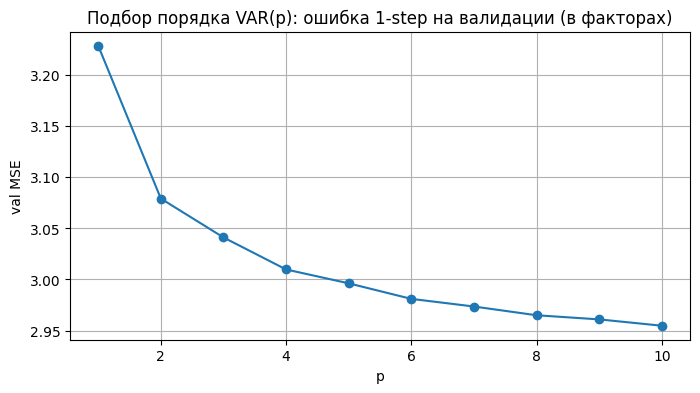

Best p = 10 val MSE = 2.9546862510842242


In [ ]:
def make_varp_xy_by_seqs(F_series, weights, p, seqs_set):
    X_list, Y_list, w_list = [], [], []
    for s, sub in df2.groupby("seq_ix", sort=False):
        if s not in seqs_set:
            continue
        idx = sub.index.to_numpy()
        f = F_series[idx]
        ww = weights[idx]
        L = f.shape[0]
        if L <= p:
            continue
        for t in range(p-1, L-1):
            if t+1 >= L:
                break
            lags = [f[t - j] for j in range(p)]
            xrow = np.concatenate(lags + [np.ones((1,))], axis=0)
            X_list.append(xrow)
            Y_list.append(f[t+1])
            w_list.append(ww[t])
    X = np.vstack(X_list).astype(np.float64)
    Y = np.vstack(Y_list).astype(np.float64)
    w = np.array(w_list, dtype=np.float64)
    return X, Y, w

train_seqs = set(seqs[n_val:])
val_seqs = set(seqs[:n_val])

def fit_regime_varp(p, lam=1e-3):
    X_tr, Y_tr, wL_tr = make_varp_xy_by_seqs(F_all, w_low,  p, train_seqs)
    _,    _,    wH_tr = make_varp_xy_by_seqs(F_all, w_high, p, train_seqs)

    B_L = fit_weighted_ridge(X_tr, Y_tr, wL_tr, lam=lam)
    B_H = fit_weighted_ridge(X_tr, Y_tr, wH_tr, lam=lam)
    return B_L, B_H

def eval_regime_varp(p, B_L, B_H):
    X_va, Y_va, wL_va = make_varp_xy_by_seqs(F_all, w_low,  p, val_seqs)
    _,    _,    wH_va = make_varp_xy_by_seqs(F_all, w_high, p, val_seqs)

    YL = predict_with_B(X_va, B_L)
    YH = predict_with_B(X_va, B_H)

    wH = wH_va.reshape(-1,1)
    Yp = (1.0 - wH) * YL + wH * YH

    mse = float(np.mean((Y_va - Yp)**2))
    return mse, (Y_va - Yp)

import pandas as pd
import matplotlib.pyplot as plt

rows = []
best = (None, np.inf, None, None, None)

for p in range(1, 11):
    B_L, B_H = fit_regime_varp(p, lam=1e-3)
    mse, E = eval_regime_varp(p, B_L, B_H)
    rows.append({"p": p, "val_mse_factors": mse})
    if mse < best[1]:
        best = (p, mse, B_L, B_H, E)

res = pd.DataFrame(rows).sort_values("p")
print(res)

plt.figure(figsize=(8,4))
plt.plot(res["p"], res["val_mse_factors"], marker="o")
plt.title("Подбор порядка VAR(p): ошибка 1-step на валидации (в факторах)")
plt.xlabel("p"); plt.ylabel("val MSE")
plt.grid(True)
plt.show()

p_star, mse_star, B_L_star, B_H_star, E_star = best
print("Best p =", p_star, "val MSE =", mse_star)

In [191]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np

def ljung_share(E, lag=20):
    ps = []
    for j in range(E.shape[1]):
        pv = acorr_ljungbox(E[:,j], lags=[lag], return_df=True)["lb_pvalue"].iloc[0]
        ps.append(pv)
    ps = np.array(ps)
    return float(np.mean(ps < 0.05)), float(np.nanmedian(ps))

share, medp = ljung_share(E_star, lag=20)
print(f"Ljung–Box p<0.05 share @lag20 (best p={p_star}):", share, "median p:", medp)


Ljung–Box p<0.05 share @lag20 (best p=10): 1.0 median p: 1.411039291517215e-131


In [ ]:
F = 8 
p = 10
lam = 1e-3
alpha = 10.0

id_cols = ["seq_ix","step_in_seq","need_prediction"]
feat_cols = [c for c in df.columns if c not in id_cols]


df2 = df.sort_values(["seq_ix","step_in_seq"]).reset_index(drop=True)
seqs = df2["seq_ix"].drop_duplicates().to_numpy()
rng = np.random.default_rng(0)
rng.shuffle(seqs)
n_val = int(0.2 * len(seqs))
val_seqs = set(seqs[:n_val])
train_seqs = set(seqs[n_val:])

is_val = df2["seq_ix"].isin(val_seqs).to_numpy()
is_train = ~is_val


X = df2[feat_cols].to_numpy(np.float64)
C = np.cov(X[is_train], rowvar=False)
eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
P = eigvecs[:, idx[:F]]
F_all = X @ P 
z_raw = np.sqrt((X**2).mean(axis=1))
z_by_step = pd.Series(z_raw[is_train]).groupby(df2.loc[is_train, "step_in_seq"]).mean().sort_index()
z_term = z_by_step.reindex(range(int(df2["step_in_seq"].max()) + 1)).interpolate().rolling(
    21, center=True, min_periods=1
).mean()

z_term_row = z_term.loc[df2["step_in_seq"]].to_numpy(np.float64)
z_resid = z_raw / (z_term_row + 1e-8)

thr = float(np.median(z_resid[is_train]))

w_high = 1.0 / (1.0 + np.exp(-alpha * (z_resid - thr)))
w_low = 1.0 - w_high

def build_varp_matrices(F_series, w_series, seq_set, p):
    """
    Возвращает:
      Xlags: (M, F*p + 1)   [f_t, f_{t-1}, ..., f_{t-p+1}, 1]
      Y:     (M, F)         f_{t+1}
      w:     (M,)           веса в момент t
      meta:  dict с индексами (глобальные индексы t), чтобы потом оценивать на need_prediction
    """
    X_list, Y_list, w_list, t_index_list = [], [], [], []

    for s, sub in df2.groupby("seq_ix", sort=False):
        if s not in seq_set:
            continue
        idx = sub.index.to_numpy()
        f = F_series[idx]
        w = w_series[idx] 
        L = f.shape[0]
        if L <= p:
            continue
        Y = f[p:L]
        lag_blocks = []
        for j in range(p):
            lag_blocks.append(f[(p-1-j):(L-1-j)])
        Xlags = np.hstack(lag_blocks)


        Xlags = np.hstack([Xlags, np.ones((L-p, 1))])

       
        ww = w[(p-1):(L-1)]

        t_idx_global = idx[(p-1):(L-1)]

        X_list.append(Xlags)
        Y_list.append(Y)
        w_list.append(ww)
        t_index_list.append(t_idx_global)

    X_all = np.vstack(X_list).astype(np.float64)
    Y_all = np.vstack(Y_list).astype(np.float64)
    w_all = np.concatenate(w_list).astype(np.float64)
    t_all = np.concatenate(t_index_list).astype(np.int64)

    return X_all, Y_all, w_all, t_all

def fit_weighted_ridge(Xm, Ym, wm, lam=1e-3):
    wm = wm.reshape(-1, 1)
    XtW = (Xm * wm).T
    G = XtW @ Xm + lam * np.eye(Xm.shape[1])
    B = np.linalg.solve(G, XtW @ Ym) 
    return B

Xtr, Ytr, wLtr, _ = build_varp_matrices(F_all, w_low,  train_seqs, p)
_,   _,   wHtr, _ = build_varp_matrices(F_all, w_high, train_seqs, p)

B_L = fit_weighted_ridge(Xtr, Ytr, wLtr, lam=lam)
B_H = fit_weighted_ridge(Xtr, Ytr, wHtr, lam=lam)

Xva, Yva, wLva, t_va = build_varp_matrices(F_all, w_low,  val_seqs, p)
_,   _,   wHva, _    = build_varp_matrices(F_all, w_high, val_seqs, p)

Yhat_L = Xva @ B_L
Yhat_H = Xva @ B_H
wH = wHva.reshape(-1, 1)
Yhat = (1.0 - wH) * Yhat_L + wH * Yhat_H  
Xhat = Yhat @ P.T
Xtrue = (Yva @ P.T)
Xtrue_real = X[t_va + 1]

need_t = df2.loc[t_va, "need_prediction"].to_numpy().astype(bool)
Xhat_eval = Xhat[need_t]
Xtrue_eval = Xtrue_real[need_t]

def r2_score(Y_true, Y_pred):
    ss_res = np.sum((Y_true - Y_pred) ** 2, axis=0)
    ss_tot = np.sum((Y_true - Y_true.mean(axis=0)) ** 2, axis=0) + 1e-12
    r2 = 1.0 - ss_res / ss_tot
    return r2

r2_dim = r2_score(Xtrue_eval, Xhat_eval)
print("R^2 mean over dims:", float(np.mean(r2_dim)))
print("R^2 median over dims:", float(np.median(r2_dim)))
print("Worst 5 dims:", pd.Series(r2_dim, index=feat_cols).sort_values().head(5))
print("Best 5 dims:", pd.Series(r2_dim, index=feat_cols).sort_values(ascending=False).head(5))

Xpers = X[t_va]
Xpers_eval = Xpers[need_t]
r2_pers = r2_score(Xtrue_eval, Xpers_eval)
print("\nPersistence R^2 mean:", float(np.mean(r2_pers)))


R^2 mean over dims: 0.272750551245565
R^2 median over dims: 0.2675649927303022
Worst 5 dims: 19    0.156275
21    0.158746
4     0.163802
1     0.169340
5     0.175611
dtype: float64
Best 5 dims: 7     0.429436
14    0.428968
20    0.419322
6     0.416848
13    0.381086
dtype: float64

Persistence R^2 mean: -0.40038210109222166
